In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

print("Đã nạp xong các thư viện cần thiết!")

Đã nạp xong các thư viện cần thiết!


In [10]:
# Đọc file dữ liệu và tự đặt tên 2 cột là 'text' và 'score'
df = pd.read_csv('sentiment_train.csv', names=['text', 'score'])

# Ép cột score về kiểu số thực (float). Dòng nào lỗi dính chữ 'score' sẽ biến thành NaN
df['score'] = pd.to_numeric(df['score'], errors='coerce')

# Loại bỏ các dòng bị lỗi trống dữ liệu (NaN) nếu có
df = df.dropna(subset=['score'])

# In ra kiểm tra cấu trúc dữ liệu sau khi lọc sạch
print("Số lượng dòng dữ liệu sạch:", len(df))
print(df.head())

Số lượng dòng dữ liệu sạch: 500
                                                text  score
1  The tool is amazing and I definitely worth the...   4.89
2  The customer service works perfectly and I abs...   4.26
3        This app is terrible, extremely frustrated.   1.55
4  The item is very disappointing, extremely frus...   1.43
5         The item is terrible, worst purchase ever.   1.39


In [5]:
df.head()

,text,score
0,text,score
1,The tool is amazing and I definitely worth the...,4.89
2,The customer service works perfectly and I abs...,4.26
3,"This app is terrible, extremely frustrated.",1.55
4,"The item is very disappointing, extremely frus...",1.43


In [12]:
X = df['text']
y = df['score']

# Biến đổi văn bản thành ma trận số
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_transformed = vectorizer.fit_transform(X)

# Chia data: 80% để train model học, 20% để giữ lại kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)
print("Đã số hóa văn bản xong!")

Đã số hóa văn bản xong!


In [13]:
# Khởi tạo thuật toán Hồi quy tuyến tính
model = LinearRegression()

# Tiến hành Train (Khớp đường thẳng hồi quy vào dữ liệu)
model.fit(X_train, y_train)
print("Mô hình Linear Regression đã được train xong!")

Mô hình Linear Regression đã được train xong!


In [14]:
from sklearn.metrics import r2_score
# Dự đoán thử trên 20% dữ liệu test
y_pred = model.predict(X_test)

# Tính sai số MSE và độ khớp R2
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Sai số bình phương trung bình (MSE): {mse:.4f} (Càng nhỏ càng tốt)")
print(f"Độ khớp dữ liệu (R2 Score): {r2:.4f} (Càng gần 1 càng tốt)")

Sai số bình phương trung bình (MSE): 0.1769 (Càng nhỏ càng tốt)
Độ khớp dữ liệu (R2 Score): 0.8930 (Càng gần 1 càng tốt)


In [15]:
def predict_sentiment_score(sample_text):
    # Biến đổi câu văn nhập vào thành số
    sample_vec = vectorizer.transform([sample_text])
    # Mô hình Linear Regression dự đoán ra một con số liên tục
    predicted_score = model.predict(sample_vec)[0]
    # Giới hạn điểm số trong khoảng từ 1 đến 5
    predicted_score = max(1.0, min(5.0, predicted_score))
    return predicted_score

# Test thử luôn câu kinh điển hôm nọ
test_text = "i don't think she is beautiful"
print(f"Câu test: '{test_text}'")
print(f"Mô hình Linear Regression dự đoán điểm số là: {predict_sentiment_score(test_text):.2f} / 5.0")

Câu test: 'i don't think she is beautiful'
Mô hình Linear Regression dự đoán điểm số là: 1.00 / 5.0


In [16]:
import joblib

# Lưu mô hình Linear Regression và bộ chuyển đổi chữ sang số TF-IDF
joblib.dump(model, 'linear_sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Đã lưu mô hình thành công thành file .pkl!")

Đã lưu mô hình thành công thành file .pkl!


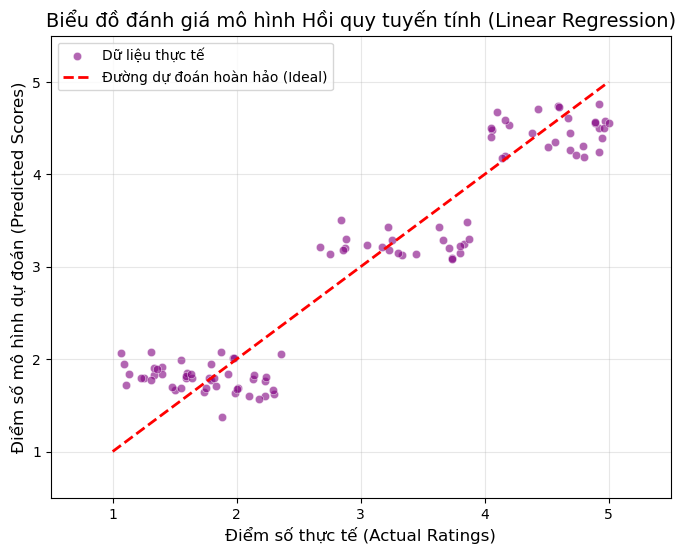

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình kích thước biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ các điểm dữ liệu thực tế vs dự đoán (Dạng chấm tròn Scatter plot)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple', label='Dữ liệu thực tế')

# Vẽ đường thẳng phân phối hoàn hảo (Nếu dự đoán đúng 100%, các điểm sẽ nằm hết trên đường này)
plt.plot([1, 5], [1, 5], color='red', linestyle='--', linewidth=2, label='Đường dự đoán hoàn hảo (Ideal)')

# Đặt tên tiêu đề và các trục
plt.title('Biểu đồ đánh giá mô hình Hồi quy tuyến tính (Linear Regression)', fontsize=14)
plt.xlabel('Điểm số thực tế (Actual Ratings)', fontsize=12)
plt.ylabel('Điểm số mô hình dự đoán (Predicted Scores)', fontsize=12)
plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)
plt.legend()
plt.grid(True, alpha=0.3)

# Hiển thị biểu đồ ngay trong file Notebook
plt.show()